In [1]:
import numpy as np    
from sympy import symbols, nsolve, cos, sin, sqrt, pi
from collections import defaultdict
import os
from PIL import Image, ImageDraw, ImageFont
import imageio
import matplotlib.pyplot as plt
import pandas as pd
import ast

In [ ]:
#改进，引进K
def calculate_energy_levels(N, y1, y2, a, E_min, E_max, k=10):
    """
    计算给定参数下的能量级别(E值)
    参数:
        N: 系统参数
        y1, y2: 势能参数
        a: 系统参数
        E_min, E_max: 能量范围
        k: 合并解的精度（小数点后k位相同则合并）
    返回:
        字典，键是n值，值是对应的E值列表
    """
    N_0 = N if N % 2 == 0 else N - 1
    n_values = np.arange(int(N_0/2 + 1))
#    n_values= n_values[1:]
    
    E_sym = symbols('E')
    
    result_dict = defaultdict(list)  # 存储最终结果

    for n in n_values:
        equation = cos(2*a*sqrt(E_sym)) + y1*sin(2*a*sqrt(E_sym))/sqrt(E_sym) \
                  - (y1**2 + y2**2)*(cos(2*a*sqrt(E_sym))-1)/(4*E_sym) \
                  - cos(2*pi*n/N)
        
        solutions = []
        for E_guess in np.linspace(E_min + 0.1, E_max, 100):
            try:
                sol = float(nsolve(equation, E_sym, E_guess, tol=1e-12))
                if E_min <= sol <= E_max:
                    solutions.append(sol)
            except:
                continue
        
        # 合并解（保留小数点后k位相同的唯一值）并排序
        merged_solutions = sorted(list({round(sol, k) for sol in solutions}))
        result_dict[n] = merged_solutions
    
     
    return dict(result_dict)


In [30]:
N = 10000
a = 0.5
E_min = 0
E_max = 400
k=10
y11 = [2,0]
y22 = [0,2]
for y1,y2 in zip(y11,y22):
    energy_levels=calculate_energy_levels(N, y1, y2, a, E_min, E_max, k=10)
    
    E_array = []
    n_array = []

    for n, E_values in energy_levels.items():
        if E_values:  # 只处理有E值的情况
            E_array.extend(E_values)
            n_array.extend([n] * len(E_values))  # 每个E值对应一个n值

    E_array = np.array(E_array)
    n_array = np.array(n_array)
    K_array=np.pi*n_array/(N*a)

    new=dict(zip(E_array,K_array))
    sorted_new = dict(sorted(new.items(), key=lambda item: item[0]))
    #print(sorted_new)

    K_array=np.pi*n_array/(N*a)*(-1)
    new_1=dict(zip(E_array,K_array))
    sorted_new_1 = dict(sorted(new_1.items(), key=lambda item: item[0]))

    file_name = f"N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}正.xlsx"
    save_path = os. path.join(fr"C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N{N}_y1{y1}_y2{y2}", file_name)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 确保目录存在

    # 将字典转换为 DataFrame（第一列是 key，第二列是 value）
    df = pd.DataFrame({
        "E": sorted_new.keys(),
        "K": sorted_new.values()
    })


字典已保存至: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N10000_y12_y20\N10000_y12_y20_a0.5_Emin0_Emax400_k10正.xlsx
字典已保存至: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N10000_y12_y20\N10000_y12_y20_a0.5_Emin0_Emax400_k10负.xlsx
字典已保存至: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N10000_y10_y22\N10000_y10_y22_a0.5_Emin0_Emax400_k10正.xlsx
字典已保存至: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N10000_y10_y22\N10000_y10_y22_a0.5_Emin0_Emax400_k10负.xlsx


In [ ]:

# 保存为 Excel 文件
df.to_excel(save_path, index=False)
print(f"字典已保存至: {save_path}")

file_name = f"N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}负.xlsx"
save_path = os. path.join(fr"C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N{N}_y1{y1}_y2{y2}", file_name)
os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 确保目录存在



# 将字典转换为 DataFrame（第一列是 key，第二列是 value）
df = pd.DataFrame({
    "E": sorted_new_1.keys(),
    "K": sorted_new_1.values()
})

# 保存为 Excel 文件
df.to_excel(save_path, index=False)
print(f"字典已保存至: {save_path}")

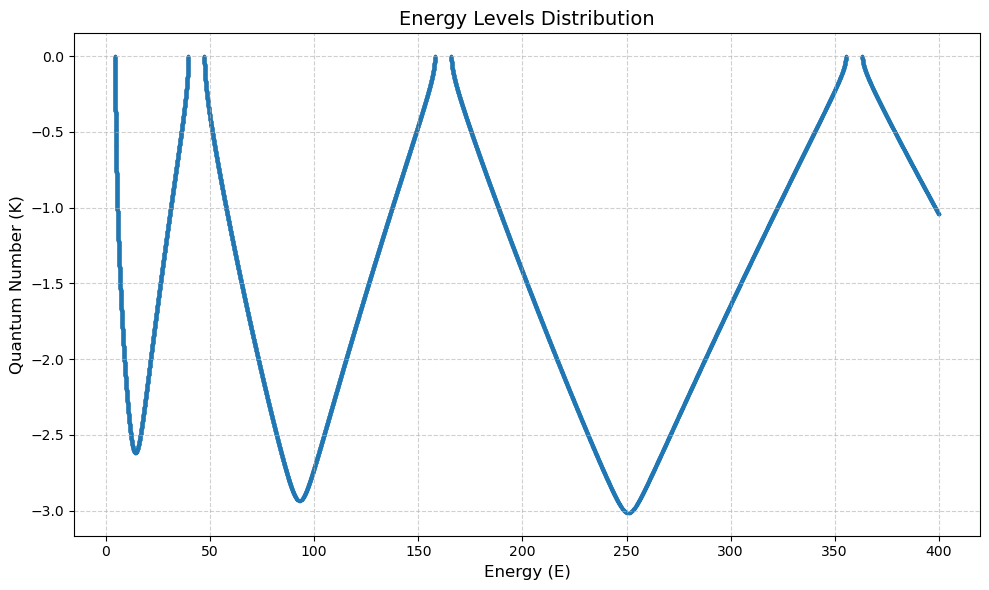

In [25]:
# 绘制图形
plt.figure(figsize=(10, 6))
plt.scatter(np.array(list(sorted_new_1.keys())),np.array(list(sorted_new_1.values())), s=2, alpha=0.7)  
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Quantum Number (K)', fontsize=12)
plt.title('Energy Levels Distribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

#plt.xlim(max(0, E_min), min(E_max, max(E_array)*1.1))
#plt.ylim(min(n_array)-0.5, max(n_array)+0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import os

file_name = f"N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}.xlsx"
save_path = os. path.join(r"C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果", file_name)
os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 确保目录存在

# 将字典转换为 DataFrame（第一列是 key，第二列是 value）
df = pd.DataFrame({
    "Key": energy_levels.keys(),
    "Value": energy_levels.values()
})

# 保存为 Excel 文件
df.to_excel(save_path, index=False)
print(f"字典已保存至: {save_path}")


字典已保存至: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N10000_y12_y22\N10000_y12_y22_a0.5_Emin0_Emax400_k10正.xlsx
字典已保存至: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N10000_y12_y22\N10000_y12_y22_a0.5_Emin0_Emax400_k10负.xlsx


In [31]:
N = 10000
y1 = 2
y2 = 2
a = 0.5
E_min = 0
E_max = 400
k=10

In [41]:
# 读取 Excel 文件
file_name = f"N{N}_y1{y1}_y2{y2}_a{a}_Emin{E_min}_Emax{E_max}_k{k}正.xlsx"
save_path = os. path.join(r"C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\能带数据\N10000_y12_y22", file_name)
loaded_df = pd.read_excel(save_path)

# 转换为字典
energy_levels = dict(zip(loaded_df["E"], loaded_df["K"]))
#print("从 Excel 加载的字典（列表格式）:", energy_levels)

E_array = []
K1_array = []
K2_array = []
K3_array = []
K4_array = []
for E, K in energy_levels.items():
    E_array.append(E)  # 使用 append 而不是 extend
    K1_array.append(K - 2 * np.pi)  # 计算单个值并存储
    K2_array.append(-K)
    K3_array.append(K)
    K4_array.append(-K + 2 * np.pi)

In [ ]:
#items = list(energy_levels.items())[1:]  
#energy_levels_1 = dict(items)
#print(energy_levels_1)

In [ ]:
E_array = []
n_array = []

for n, E_values in energy_levels.items():
    if E_values:  # 只处理有E值的情况
        E_array.extend(E_values)
        n_array.extend([n] * len(E_values))  # 每个E值对应一个n值

E_array = np.array(E_array)
n_array = np.array(n_array)
K_array=np.pi*n_array/(N*a)

new=dict(zip(E_array,K_array))
sorted_new = dict(sorted(new.items(), key=lambda item: item[0]))
#print(sorted_new)

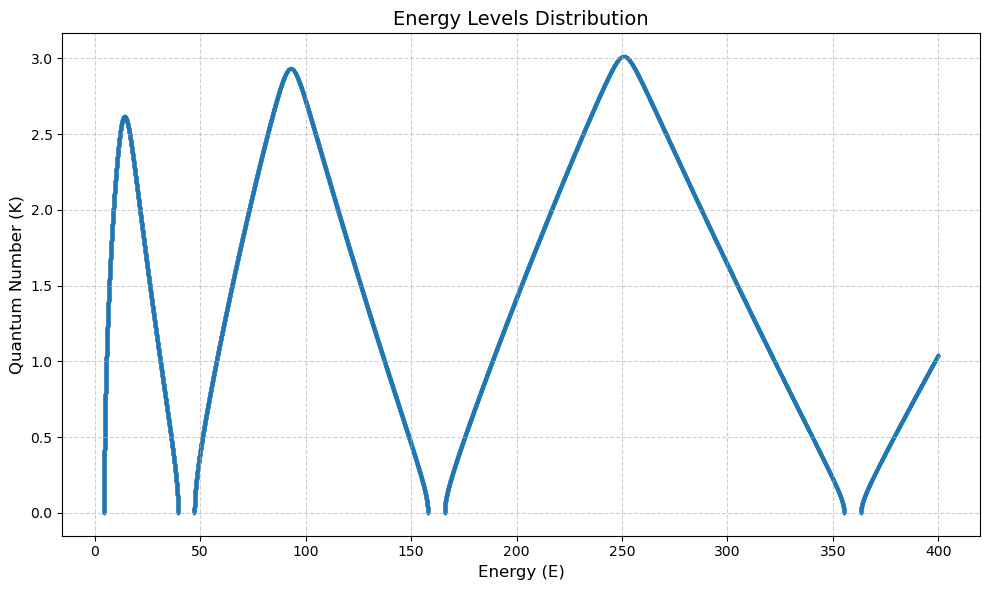

In [7]:
# 绘制图形
plt.figure(figsize=(10, 6))
plt.scatter(np.array(list(sorted_new.keys())),np.array(list(sorted_new.values())), s=2, alpha=0.7)  
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Quantum Number (K)', fontsize=12)
plt.title('Energy Levels Distribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

#plt.xlim(max(0, E_min), min(E_max, max(E_array)*1.1))
#plt.ylim(min(n_array)-0.5, max(n_array)+0.5)

plt.tight_layout()
plt.show()

In [12]:
E_array = np.array(list(sorted_new.keys()))     # E数组
K_array = np.array(list(sorted_new.values()))   # K数组
K_array = np.array(list(sorted_new.values())).flatten()  # 转换为 (288,)
y_6=2*a*np.sin(2*K_array*a)
y_7=np.sin(2*a*E_array**0.5)*(a*E_array**(-0.5)+(y1/2-a*(y1**2+y2**2)/4)*E_array**(-1.5))
y_8=np.cos(2*a*E_array**0.5)*(a*y1*E_array**(-1)+((y1**2+y2**2)/4)*E_array**(-2))
y_9=((y1**2+y2**2)/4)*E_array**(-2)
Group_velocity=y_6/(y_7-y_8+y_9)

Group_velocity=abs(Group_velocity)
len(Group_velocity),len(E_array)

(29076, 29076)

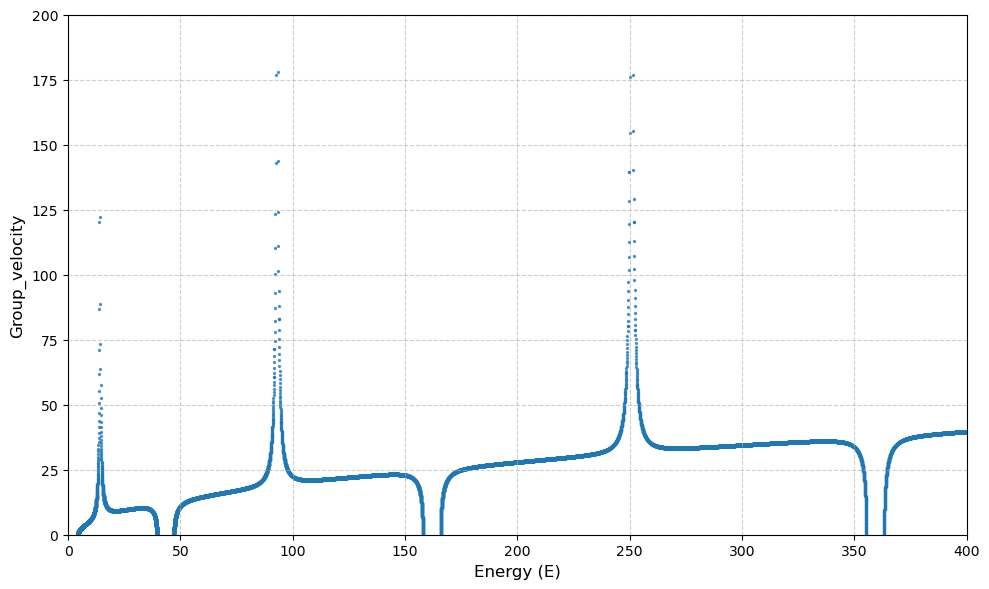

In [13]:

plt.figure(figsize=(10, 6))
plt.scatter(E_array,Group_velocity, s=2, alpha=0.7)  # 使用散点图
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Group_velocity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# 调整坐标轴范围
plt.xlim(0,400)
plt.ylim(0,200)

# 显示图形
plt.tight_layout()
plt.show()

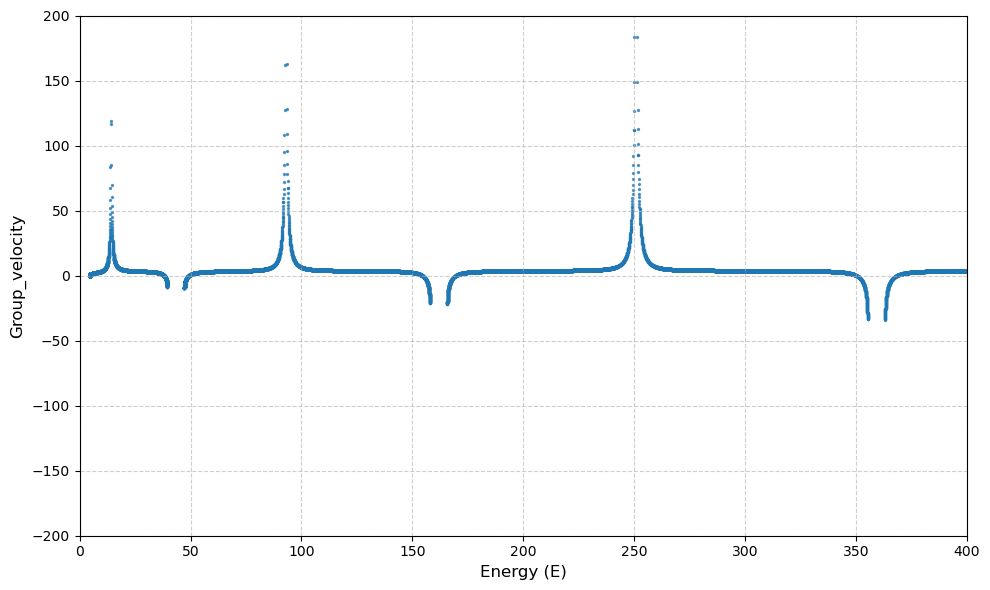

In [19]:
# 绘制图形
Group_velocity_1=Group_velocity-(4*(E_array))**0.5+4

plt.figure(figsize=(10, 6))
plt.scatter(E_array,Group_velocity_1, s=2, alpha=0.7)  # 使用散点图
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Group_velocity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
# 调整坐标轴范围
plt.xlim(0,400)
plt.ylim(-200,200)

# 显示图形
plt.tight_layout()
plt.show()

图像已保存至: C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果\群速度_xlim0-400_ylim0-200.png


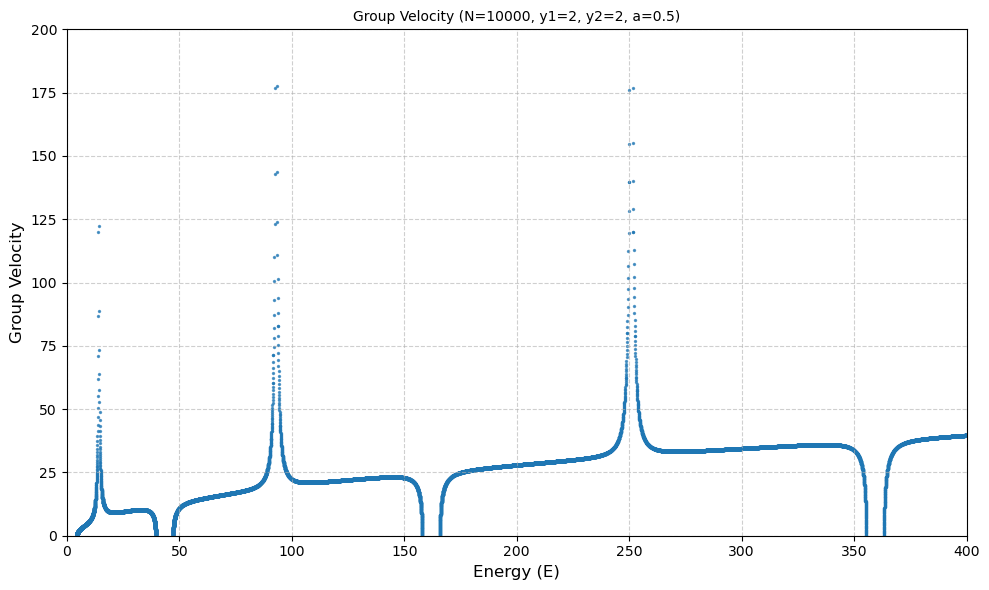

In [110]:
import matplotlib.pyplot as plt
import os

# 参数设置
xlim = (0, 400)
ylim = (0, 200)

# 定义保存路径
save_dir = r"C:\Users\taoji\Desktop\结果\2025.4.12后_Python运行结果"
os.makedirs(save_dir, exist_ok=True)
image_name = f"群速度_xlim{xlim[0]}-{xlim[1]}_ylim{ylim[0]}-{ylim[1]}.png"
save_path = os.path.join(save_dir, image_name)

# 绘制图形
plt.figure(figsize=(10, 6))
plt.scatter(E_array, Group_velocity, s=2, alpha=0.7)
plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Group Velocity', fontsize=12)
plt.title(f"Group Velocity (N={N}, y1={y1}, y2={y2}, a={a})", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(*xlim)
plt.ylim(*ylim)
plt.tight_layout()

# 保存图像
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"图像已保存至: {save_path}")
plt.show()

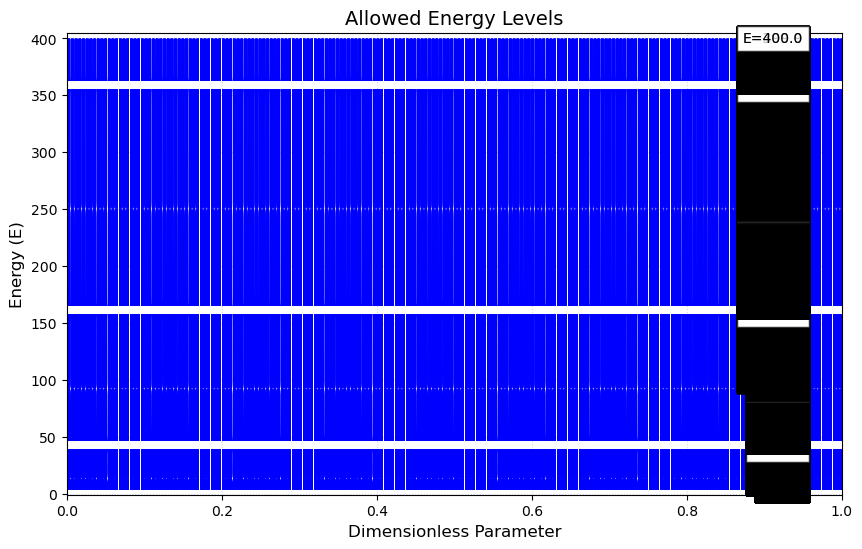

In [170]:
# 创建图形
plt.figure(figsize=(10, 6))

# 绘制水平线
for E in E_array:
    plt.axhline(y=E, color='blue', linestyle='--', linewidth=0.5, alpha=0.7)

# 标注能量值（可选）
for i, E in enumerate(E_array):
    plt.text(0.95, E, f"E={E:.1f}", ha='right', va='center', 
             transform=plt.gca().get_yaxis_transform(),
             bbox=dict(facecolor='white', alpha=0.5))

# 坐标轴设置
plt.xlabel('Dimensionless Parameter', fontsize=12)
plt.ylabel('Energy (E)', fontsize=12)
plt.title('Allowed Energy Levels', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.ylim(min(E_array)-5, max(E_array)+5)  # 自动扩展y轴范围

# 保存图像
save_path = "allowed_energy_levels.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()